=== 目标速度引导函数测试 ===

模拟参数: B=2, P=3, T=8, D=3

1. 生成测试轨迹数据...
轨迹数据形状: torch.Size([2, 3, 8, 3])

实际速度分析:
Batch 0: 平均速度 = 0.576 m/s, 速度范围 = [0.576, 0.576]
Batch 1: 平均速度 = 1.720 m/s, 速度范围 = [1.720, 1.720]

2. 准备输入数据...
目标速度: 6.0 m/s
时间步: tensor([0.0500, 0.0800])

3. 测试目标速度引导函数...

--- 基础版本测试 ---
=== 目标速度引导调试 ===
输入x形状: torch.Size([2, 3, 8, 3]), 需要梯度: True
目标速度: 6.0 m/s
  时间步 1: 速度=0.576m/s, 误差=-5.424, 损失=3.415137
  时间步 2: 速度=0.576m/s, 误差=-5.424, 损失=3.415137
  时间步 3: 速度=0.576m/s, 误差=-5.424, 损失=3.415137
有效时间步: 14, 平均速度损失: 3.188047
速度损失: 3.188047170639038, 需要梯度: True
完整梯度范数: 0.05745650455355644
自车梯度 - 范数: 0.057457, 均值: 0.000000, 非零比例: 0.167

--- 高级版本测试 ---
目标速度: 6.0 m/s, 容差: 1.0 m/s
速度跟踪损失: 4.851949
加速度损失: 0.000000
速度一致性损失: 0.000000
总速度损失: 4.851949
✅ 目标速度引导函数执行成功!

4. 梯度分析:
基础版本梯度范数: 0.057457
高级版本梯度范数: 0.142857

基础版本自车梯度:
  总范数: 0.057457
  x梯度 - 范数: 0.057162, 均值: 0.000000
  y梯度 - 范数: 0.005812, 均值: 0.000000
  heading梯度 - 范数: 0.000000, 均值: 0.000000

高级版本自车梯度:
  总范数: 0.142857
  x梯度 - 范数: 0.14205

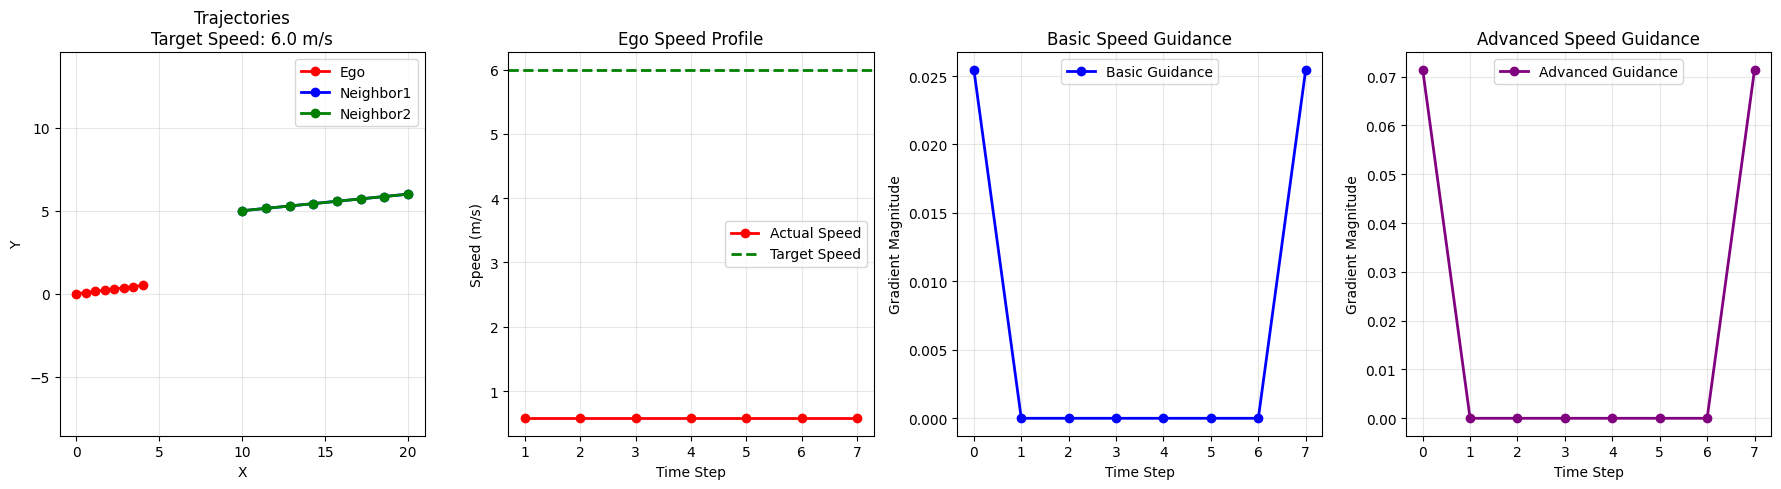

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def target_speed_guidance_fn(x, t, cond, inputs, *args, **kwargs):
    """
    目标速度引导函数
    x: [B, P, T, 3] - (x, y, heading)
    """
    B, P, T, _ = x.shape
    device = x.device
    
    # 确保x需要梯度
    x = x.detach().requires_grad_(True)
    
    # 只在特定时间范围内应用引导
    mask_diffusion_time = (t < 0.1) & (t > 0.005)
    if not mask_diffusion_time.any():
        return torch.zeros_like(x)
    
    print(f"=== 目标速度引导调试 ===")
    print(f"输入x形状: {x.shape}, 需要梯度: {x.requires_grad}")
    
    # 计算目标速度损失
    speed_loss = compute_target_speed_loss(x, inputs)
    
    print(f"速度损失: {speed_loss.item()}, 需要梯度: {speed_loss.requires_grad}")
    
    # 计算梯度
    if speed_loss != 0 and speed_loss.requires_grad:
        grad_full = torch.autograd.grad(speed_loss, x, retain_graph=False)[0]
        
        print(f"完整梯度范数: {torch.norm(grad_full).item()}")
        
        # 只保留自车梯度，其他交通参与者梯度置零
        grad_x = torch.zeros_like(x)
        grad_x[:, 0:1] = grad_full[:, 0:1]  # 只保留自车(索引0)的梯度
        
        ego_grad_norm = torch.norm(grad_x[:, 0]).item()
        ego_grad_mean = grad_x[:, 0].mean().item()
        ego_nonzero_ratio = (torch.abs(grad_x[:, 0]) > 1e-6).float().mean().item()
        
        print(f"自车梯度 - 范数: {ego_grad_norm:.6f}, 均值: {ego_grad_mean:.6f}, 非零比例: {ego_nonzero_ratio:.3f}")
        
    else:
        grad_x = torch.zeros_like(x)
        print("❌ 速度损失为0或不需要梯度")
    
    return grad_x

def compute_target_speed_loss(x, inputs):
    """
    计算目标速度损失
    损失函数设计：鼓励轨迹速度接近目标速度
    """
    B, P, T, _ = x.shape
    device = x.device
    
    # 获取目标速度 (可以从inputs中获取或设置默认值)
    target_speed = inputs.get("target_speed", torch.tensor(5.0, device=device))  # m/s
    print(f"目标速度: {target_speed.item()} m/s")
    
    total_loss = torch.tensor(0.0, device=device, requires_grad=True)
    valid_steps = 0
    
    # 只考虑自车的速度
    for b in range(B):
        for t in range(1, T):  # 从第2个时间步开始计算速度
            # 计算当前时间步的速度 (通过位置差分)
            current_pos = x[b, 0, t, :2]    # 当前位置
            prev_pos = x[b, 0, t-1, :2]     # 前一个位置
            
            # 计算位移
            displacement = current_pos - prev_pos
            current_speed = torch.norm(displacement)  # 瞬时速度
            
            # 速度误差损失 - 使用平滑的L2损失
            speed_error = current_speed - target_speed
            speed_loss = torch.log(1 + speed_error ** 2)  # 平滑的L2损失
            
            total_loss = total_loss + speed_loss
            valid_steps += 1
            
            # 调试信息
            if valid_steps <= 3:  # 只打印前几个
                print(f"  时间步 {t}: 速度={current_speed.item():.3f}m/s, 误差={speed_error.item():.3f}, 损失={speed_loss.item():.6f}")
    
    if valid_steps > 0:
        avg_loss = total_loss / valid_steps
        print(f"有效时间步: {valid_steps}, 平均速度损失: {avg_loss.item():.6f}")
        return avg_loss
    else:
        print("没有有效的时间步用于速度计算")
        return torch.tensor(0.0, device=device, requires_grad=True)

def compute_target_speed_loss_advanced(x, inputs):
    """
    高级版本：考虑更多速度相关因素的目标速度损失
    """
    B, P, T, _ = x.shape
    device = x.device
    
    # 获取目标速度参数
    target_speed = inputs.get("target_speed", torch.tensor(5.0, device=device))
    speed_tolerance = inputs.get("speed_tolerance", torch.tensor(1.0, device=device))  # 速度容差
    max_acceleration = inputs.get("max_acceleration", torch.tensor(3.0, device=device))  # 最大加速度
    
    print(f"目标速度: {target_speed.item()} m/s, 容差: {speed_tolerance.item()} m/s")
    
    # 使用torch.tensor来保持梯度
    total_loss = torch.tensor(0.0, device=device, requires_grad=True)
    valid_components = 0
    
    # 1. 速度跟踪损失
    speed_tracking_loss = torch.tensor(0.0, device=device, requires_grad=True)
    speed_steps = 0
    
    for b in range(B):
        for t in range(1, T):
            current_pos = x[b, 0, t, :2]
            prev_pos = x[b, 0, t-1, :2]
            
            displacement = current_pos - prev_pos
            current_speed = torch.norm(displacement)
            
            # 使用分段损失函数
            speed_diff = torch.abs(current_speed - target_speed)
            if speed_diff <= speed_tolerance:
                # 在容差范围内，使用较小的二次损失
                speed_tracking_loss = speed_tracking_loss + (speed_diff / speed_tolerance) ** 2
            else:
                # 超出容差，使用线性损失
                speed_tracking_loss = speed_tracking_loss + speed_diff / speed_tolerance
            
            speed_steps += 1
    
    if speed_steps > 0:
        speed_tracking_loss = speed_tracking_loss / speed_steps
        total_loss = total_loss + speed_tracking_loss
        valid_components += 1
        print(f"速度跟踪损失: {speed_tracking_loss.item():.6f}")
    
    # 2. 加速度平滑损失
    acceleration_loss = torch.tensor(0.0, device=device, requires_grad=True)
    acc_steps = 0
    
    for b in range(B):
        for t in range(2, T):  # 需要3个点计算加速度
            pos_t = x[b, 0, t, :2]
            pos_t1 = x[b, 0, t-1, :2]
            pos_t2 = x[b, 0, t-2, :2]
            
            speed_t = pos_t - pos_t1
            speed_t1 = pos_t1 - pos_t2
            
            acceleration = torch.norm(speed_t - speed_t1)
            
            # 惩罚过大的加速度
            if acceleration > max_acceleration:
                acceleration_loss = acceleration_loss + (acceleration - max_acceleration) ** 2
            
            acc_steps += 1
    
    if acc_steps > 0:
        acceleration_loss = acceleration_loss / acc_steps
        total_loss = total_loss + 0.1 * acceleration_loss  # 较小的权重
        valid_components += 1
        print(f"加速度损失: {acceleration_loss.item():.6f}")
    
    # 3. 速度一致性损失 (相邻时间步速度变化平滑)
    consistency_loss = torch.tensor(0.0, device=device, requires_grad=True)
    consistency_steps = 0
    
    for b in range(B):
        for t in range(1, T-1):
            speed_t = torch.norm(x[b, 0, t, :2] - x[b, 0, t-1, :2])
            speed_t1 = torch.norm(x[b, 0, t+1, :2] - x[b, 0, t, :2])
            
            speed_change = torch.abs(speed_t1 - speed_t)
            consistency_loss = consistency_loss + speed_change ** 2
            consistency_steps += 1
    
    if consistency_steps > 0:
        consistency_loss = consistency_loss / consistency_steps
        total_loss = total_loss + 0.05 * consistency_loss  # 更小的权重
        valid_components += 1
        print(f"速度一致性损失: {consistency_loss.item():.6f}")
    
    if valid_components > 0:
        print(f"总速度损失: {total_loss.item():.6f}")
        return total_loss
    else:
        return torch.tensor(0.0, device=device, requires_grad=True)

def expand_dims(tensor, target_dim):
    """维度扩展函数"""
    current_dim = tensor.dim()
    new_shape = tensor.shape + (1,) * (target_dim - current_dim)
    return tensor.reshape(new_shape)

def test_target_speed_guidance():
    """测试目标速度引导函数"""
    print("=== 目标速度引导函数测试 ===\n")
    
    # 设置随机种子
    torch.manual_seed(42)
    
    # 模拟参数
    B = 2  # batch size
    P = 3  # 智能体数量
    T = 8  # 时间步数
    D = 3  # 状态维度
    
    print(f"模拟参数: B={B}, P={P}, T={T}, D={D}")
    
    # 生成测试轨迹数据
    print("\n1. 生成测试轨迹数据...")
    
    # 自车轨迹 - 创建不同速度的轨迹
    ego_traj = torch.zeros(B, 1, T, D)
    
    # Batch 0: 速度较慢的轨迹
    ego_traj[0, 0, :, 0] = torch.linspace(0, 4, T)   # x: 0->4 (慢速)
    ego_traj[0, 0, :, 1] = torch.linspace(0, 0.5, T) # y: 0->0.5
    ego_traj[0, 0, :, 2] = 0.0
    
    # Batch 1: 速度较快的轨迹  
    ego_traj[1, 0, :, 0] = torch.linspace(0, 12, T)  # x: 0->12 (快速)
    ego_traj[1, 0, :, 1] = torch.linspace(0, 1, T)   # y: 0->1
    ego_traj[1, 0, :, 2] = 0.0
    
    # 邻居轨迹
    neighbor_traj = torch.zeros(B, P-1, T, D)
    neighbor_traj[:, :, :, 0] = torch.linspace(10, 20, T).unsqueeze(0).unsqueeze(0)
    neighbor_traj[:, :, :, 1] = torch.linspace(5, 6, T).unsqueeze(0).unsqueeze(0)
    
    # 合并轨迹
    x = torch.cat([ego_traj, neighbor_traj], dim=1)
    
    print(f"轨迹数据形状: {x.shape}")
    
    # 计算实际速度用于验证
    print("\n实际速度分析:")
    for b in range(B):
        speeds = []
        for t in range(1, T):
            speed = torch.norm(x[b, 0, t, :2] - x[b, 0, t-1, :2])
            speeds.append(speed.item())
        avg_speed = np.mean(speeds)
        print(f"Batch {b}: 平均速度 = {avg_speed:.3f} m/s, 速度范围 = [{min(speeds):.3f}, {max(speeds):.3f}]")
    
    # 准备输入数据
    print("\n2. 准备输入数据...")
    
    # 设置目标速度
    target_speed = torch.tensor(6.0)  # 6 m/s
    
    # 时间步
    t = torch.tensor([[0.05], [0.08]], dtype=torch.float32)
    
    inputs = {
        "target_speed": target_speed,
        "speed_tolerance": torch.tensor(1.0),
        "max_acceleration": torch.tensor(3.0),
        "neighbor_current_mask": torch.zeros(B, P-1, dtype=torch.bool)
    }
    
    cond = None
    
    print(f"目标速度: {target_speed.item()} m/s")
    print(f"时间步: {t.squeeze()}")
    
    # 测试目标速度引导函数
    print("\n3. 测试目标速度引导函数...")
    
    x_requires_grad = x.clone().requires_grad_(True)
    
    try:
        # 使用基础版本
        print("\n--- 基础版本测试 ---")
        speed_grad_basic = target_speed_guidance_fn(x_requires_grad, t, cond, inputs)
        
        # 使用高级版本
        print("\n--- 高级版本测试 ---")
        def advanced_guidance_fn(x, t, cond, inputs, *args, **kwargs):
            # 临时修改使用高级损失函数
            B, P, T, _ = x.shape
            device = x.device
            x = x.detach().requires_grad_(True)
            
            mask_diffusion_time = (t < 0.1) & (t > 0.005)
            if not mask_diffusion_time.any():
                return torch.zeros_like(x)
            
            speed_loss = compute_target_speed_loss_advanced(x, inputs)
            
            if speed_loss != 0 and speed_loss.requires_grad:
                grad_full = torch.autograd.grad(speed_loss, x, retain_graph=False)[0]
                grad_x = torch.zeros_like(x)
                grad_x[:, 0:1] = grad_full[:, 0:1]
                return grad_x
            else:
                return torch.zeros_like(x)
        
        speed_grad_advanced = advanced_guidance_fn(x_requires_grad, t, cond, inputs)
        
        print("✅ 目标速度引导函数执行成功!")
        
        # 分析梯度
        print(f"\n4. 梯度分析:")
        print(f"基础版本梯度范数: {torch.norm(speed_grad_basic):.6f}")
        print(f"高级版本梯度范数: {torch.norm(speed_grad_advanced):.6f}")
        
        # 检查自车梯度
        for version_name, grad in [("基础版本", speed_grad_basic), ("高级版本", speed_grad_advanced)]:
            ego_grad = grad[:, 0]
            ego_norm = torch.norm(ego_grad).item()
            print(f"\n{version_name}自车梯度:")
            print(f"  总范数: {ego_norm:.6f}")
            
            for d in range(3):
                dim_name = ["x", "y", "heading"][d]
                dim_grad = ego_grad[..., d]
                dim_norm = torch.norm(dim_grad).item()
                dim_mean = dim_grad.mean().item()
                print(f"  {dim_name}梯度 - 范数: {dim_norm:.6f}, 均值: {dim_mean:.6f}")
        
        # 测试在扩散模型中的应用
        print(f"\n5. 扩散模型引导测试:")
        
        # 模拟噪声预测
        noise_pred = torch.randn_like(x) * 0.1
        
        # 时间相关参数
        sigma_t = torch.tensor([0.5, 0.6])
        
        # 应用Classifier Guidance
        guidance_scale = 2.0
        sigma_t_expanded = expand_dims(sigma_t, x.dim())
        
        # 基础版本引导
        guided_noise_basic = noise_pred - guidance_scale * sigma_t_expanded * speed_grad_basic
        
        # 高级版本引导
        guided_noise_advanced = noise_pred - guidance_scale * sigma_t_expanded * speed_grad_advanced
        
        print(f"引导前噪声范数: {torch.norm(noise_pred):.6f}")
        print(f"基础版本引导后噪声范数: {torch.norm(guided_noise_basic):.6f}")
        print(f"高级版本引导后噪声范数: {torch.norm(guided_noise_advanced):.6f}")
        print(f"基础版本变化量: {torch.norm(guided_noise_basic - noise_pred):.6f}")
        print(f"高级版本变化量: {torch.norm(guided_noise_advanced - noise_pred):.6f}")
        
        # 可视化
        visualize_speed_guidance(x, speed_grad_basic, speed_grad_advanced, target_speed.item())
        
    except Exception as e:
        print(f"❌ 错误: {e}")
        import traceback
        traceback.print_exc()

def visualize_speed_guidance(x, grad_basic, grad_advanced, target_speed):
    """可视化速度引导结果"""
    plt.figure(figsize=(18, 5))
    
    # 1. 轨迹和速度图
    plt.subplot(1, 4, 1)
    b = 0  # 只看第一个batch
    
    colors = ['red', 'blue', 'green']
    labels = ['Ego', 'Neighbor1', 'Neighbor2']
    
    for p in range(x.shape[1]):
        plt.plot(x[b, p, :, 0].detach().numpy(), 
                 x[b, p, :, 1].detach().numpy(), 
                 'o-', color=colors[p], label=labels[p], linewidth=2)
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Trajectories\nTarget Speed: {target_speed} m/s')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    
    # 2. 计算并显示实际速度
    plt.subplot(1, 4, 2)
    speeds = []
    for t in range(1, x.shape[2]):
        speed = torch.norm(x[b, 0, t, :2] - x[b, 0, t-1, :2]).item()
        speeds.append(speed)
    
    plt.plot(range(1, x.shape[2]), speeds, 'o-', color='red', linewidth=2, label='Actual Speed')
    plt.axhline(y=target_speed, color='green', linestyle='--', linewidth=2, label='Target Speed')
    plt.xlabel('Time Step')
    plt.ylabel('Speed (m/s)')
    plt.title('Ego Speed Profile')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. 基础版本梯度
    plt.subplot(1, 4, 3)
    grad_magnitude_basic = torch.norm(grad_basic, dim=-1)[b, 0].detach().numpy()
    plt.plot(grad_magnitude_basic, 'o-', color='blue', linewidth=2, label='Basic Guidance')
    plt.xlabel('Time Step')
    plt.ylabel('Gradient Magnitude')
    plt.title('Basic Speed Guidance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4. 高级版本梯度
    plt.subplot(1, 4, 4)
    grad_magnitude_advanced = torch.norm(grad_advanced, dim=-1)[b, 0].detach().numpy()
    plt.plot(grad_magnitude_advanced, 'o-', color='purple', linewidth=2, label='Advanced Guidance')
    plt.xlabel('Time Step')
    plt.ylabel('Gradient Magnitude')
    plt.title('Advanced Speed Guidance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('speed_guidance_validation.png', dpi=150, bbox_inches='tight')
    print("\n✅ 可视化已保存为 'speed_guidance_validation.png'")

if __name__ == "__main__":
    test_target_speed_guidance()